In [1]:
import os
import pandas as pd
import numpy as np
import datetime as dt
import pickle
import shutil
import boto3
from tqdm import tqdm
import sys
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, spearmanr

try:
    import xmltodict
except:
    ! pip install xmltodict

try:
    import optbinning
except:
    ! pip install optbinning

# silence warnings
import warnings
warnings.filterwarnings('ignore')

In [2]:
print(f'Latest run date: {dt.datetime.today()}')

Latest run date: 2025-03-03 22:24:02.478355


#### Functions

In [3]:
# download from s3
def download_from_s3(str_local_path, str_bucket_path, str_project):
    # init client
    cls_client = boto3.client(
        's3',
    )
    # download file
    cls_client.download_file(
        str_project, 
        str_bucket_path, 
        str_local_path,
    )

In [4]:
def get_tier(flt_ecnl, dict_tiers):
    if flt_ecnl <= dict_tiers['A1']:
        return 'A1'
    elif flt_ecnl <= dict_tiers['A']:
        return 'A'
    elif flt_ecnl <= dict_tiers['B']:
        return 'B'
    elif flt_ecnl <= dict_tiers['C']:
        return 'C'
    elif flt_ecnl <= dict_tiers['D']:
        return 'D'
    else:
        return 'Decline'

#### Constants

In [5]:
# project
str_project = os.getcwd().split('/')[4].replace('_','-')
print(f'Project: {str_project}')

# task
str_task = os.getcwd().split('/')[5]
print(f'Task: {str_task}')

# subtask
str_subtask = os.getcwd().split('/')[6]
print(f'Subtask: {str_subtask}')

str_dirname_output = './output'

# dict tiers
dict_tiers = {
    'A1': 0.0760,
    'A': 0.1320,
    'B': 0.2650,
    'C': 0.3220,
    'D': 0.3500, 
}

# factor 24 to 72
flt_factor_24_to_72 = 2.36

# pd threshold
flt_threshold_pd = 0.6

Project: 20241112-simple-model-test
Task: 13_60_in_720_dl
Subtask: 10_swap_in_swap_out


#### Make output directory

In [6]:
try:
    os.mkdir(str_dirname_output)
except:
    pass

#### Import scorecard predictions

In [7]:
list_cols = [
    'accountid',
    'request_datetime',
    'PD',
    'LGD',
    'ECNL',
]
str_filename = 'df_predictions_grouped.gzip'
str_local_path = f'../03_get_predictions/output/{str_filename}'
df_dlv2 = pd.read_parquet(
    str_local_path,
    columns=list_cols,
)
# rename
dict_rename = {
    'LGD': 'lgd_dlv2',
    'PD': 'pd_dlv2',
    'ECNL': 'ecnl_dlv2',
}
df_dlv2.rename(columns=dict_rename, inplace=True)
# show
df_dlv2

,accountid,request_datetime,pd_dlv2,lgd_dlv2,ecnl_dlv2
0,8321703,2024-11-27 21:53:12+00:00,0.226087,0.635684,0.317471
1,8353245,2024-12-04 23:32:24+00:00,0.087583,0.635684,0.122984
2,8375603,2024-12-02 23:02:52+00:00,0.123767,0.605262,0.165476
3,8380765,2024-12-10 04:19:45+00:00,0.239989,0.615474,0.419352
4,8383502,2024-11-27 05:41:46+00:00,0.054071,0.605262,0.072293
...,...,...,...,...,...
9995,8627588,2025-02-07 06:40:52+00:00,0.201369,0.635684,0.282762
9996,8627590,2025-02-07 06:41:04+00:00,0.219424,0.635684,0.308115
9997,8627613,2025-02-07 06:47:03+00:00,0.067110,0.605262,0.089726
9998,8627659,2025-02-07 06:57:18+00:00,0.147441,0.605262,0.197129


#### Get Gen 12 predictions

In [8]:
list_cols = [
    'accountid',
    'pd',
    'lgd',
    'ecnl',
]
str_filename = 'df_predictions_grouped.gzip'
str_local_path = f'../04_pricing_distribution/output/{str_filename}'
df_gen12 = pd.read_parquet(
    str_local_path,
    columns=list_cols,
)
# rename
dict_rename = {
    'pd': 'pd_gen12',
    'lgd': 'lgd_gen12',
    'ecnl': 'ecnl_gen12'
}
df_gen12.rename(columns=dict_rename, inplace=True)
# show
df_gen12

,accountid,pd_gen12,lgd_gen12,ecnl_gen12
0,8321703,0.115847,0.630854,0.172474
1,8353245,0.089682,0.563194,0.119200
2,8375603,0.043439,0.591126,0.060600
3,8380765,0.131776,0.561194,0.174526
4,8383502,0.036059,0.573853,0.048835
...,...,...,...,...
9995,8627588,0.305816,0.729014,0.526148
9996,8627590,0.303960,0.728410,0.522523
9997,8627613,0.176644,0.654692,0.272928
9998,8627659,0.306193,0.646098,0.466880


#### Join

In [9]:
# join
df = pd.merge(
    left=df_gen12,
    right=df_dlv2,
    on='accountid',
    how='inner',
)
# save memory
del df_gen12
del df_dlv2
# show
df

,accountid,pd_gen12,lgd_gen12,ecnl_gen12,request_datetime,pd_dlv2,lgd_dlv2,ecnl_dlv2
0,8321703,0.115847,0.630854,0.172474,2024-11-27 21:53:12+00:00,0.226087,0.635684,0.317471
1,8353245,0.089682,0.563194,0.119200,2024-12-04 23:32:24+00:00,0.087583,0.635684,0.122984
2,8375603,0.043439,0.591126,0.060600,2024-12-02 23:02:52+00:00,0.123767,0.605262,0.165476
3,8380765,0.131776,0.561194,0.174526,2024-12-10 04:19:45+00:00,0.239989,0.615474,0.419352
4,8383502,0.036059,0.573853,0.048835,2024-11-27 05:41:46+00:00,0.054071,0.605262,0.072293
...,...,...,...,...,...,...,...,...
9995,8627588,0.305816,0.729014,0.526148,2025-02-07 06:40:52+00:00,0.201369,0.635684,0.282762
9996,8627590,0.303960,0.728410,0.522523,2025-02-07 06:41:04+00:00,0.219424,0.635684,0.308115
9997,8627613,0.176644,0.654692,0.272928,2025-02-07 06:47:03+00:00,0.067110,0.605262,0.089726
9998,8627659,0.306193,0.646098,0.466880,2025-02-07 06:57:18+00:00,0.147441,0.605262,0.197129


#### Get the raw data

In [10]:
str_filename = 'df.gzip'
str_uri = f's3://{str_project}/parse_all_apps/04_parse_payloads_dl/{str_filename}'
df_tmp = pd.read_parquet(str_uri)
df_tmp['amtfinanced__app'] = df_tmp['amtfinanced__app'].replace(0, np.nan)
df_tmp['bookvalue__app'] = df_tmp['bookvalue__app'].replace(0, np.nan)
df_tmp['ENG-loan_to_value'] = df_tmp['amtfinanced__app'] / df_tmp['bookvalue__app']
df_tmp['ENG-loan_to_value'] = df_tmp['ENG-loan_to_value'].fillna(1.27)
df_tmp['ENG-loan_to_value'] = df_tmp['ENG-loan_to_value'].mask(df_tmp['ENG-loan_to_value'] > 2, 2)

# group
df_tmp = df_tmp.groupby(by='accountid', as_index=False).agg({
    'intopenbktype__app': 'first',
    'ENG-loan_to_value': 'first',
    'strdealershiptrackertype__app': 'first',
    'fltgrossmonthly__income_sum': 'sum',
    'miles_odometer__app': 'first',
})
# show
df_tmp

,accountid,intopenbktype__app,ENG-loan_to_value,strdealershiptrackertype__app,fltgrossmonthly__income_sum,miles_odometer__app
0,8321703,NaN,1.304611,Referral,4379.20,69144
1,8353245,NaN,1.219764,Referral,8923.01,97249
2,8375603,NaN,1.101235,Referral,8233.33,56150
3,8380765,NaN,1.135986,Referral,6998.09,30237
4,8383502,NaN,0.954679,Referral,10034.96,52621
...,...,...,...,...,...,...
9995,8627588,NaN,1.243941,Franchise,7401.00,40301
9996,8627590,NaN,1.217199,Franchise,7500.00,79000
9997,8627613,NaN,0.993862,Franchise,10833.00,42200
9998,8627659,NaN,0.967878,Franchise,5400.00,86000


#### Join

In [11]:
df = pd.merge(
    left=df,
    right=df_tmp,
    on='accountid',
    how='left',
)
# show
df

,accountid,pd_gen12,lgd_gen12,ecnl_gen12,request_datetime,pd_dlv2,lgd_dlv2,ecnl_dlv2,intopenbktype__app,ENG-loan_to_value,strdealershiptrackertype__app,fltgrossmonthly__income_sum,miles_odometer__app
0,8321703,0.115847,0.630854,0.172474,2024-11-27 21:53:12+00:00,0.226087,0.635684,0.317471,NaN,1.304611,Referral,4379.20,69144
1,8353245,0.089682,0.563194,0.119200,2024-12-04 23:32:24+00:00,0.087583,0.635684,0.122984,NaN,1.219764,Referral,8923.01,97249
2,8375603,0.043439,0.591126,0.060600,2024-12-02 23:02:52+00:00,0.123767,0.605262,0.165476,NaN,1.101235,Referral,8233.33,56150
3,8380765,0.131776,0.561194,0.174526,2024-12-10 04:19:45+00:00,0.239989,0.615474,0.419352,NaN,1.135986,Referral,6998.09,30237
4,8383502,0.036059,0.573853,0.048835,2024-11-27 05:41:46+00:00,0.054071,0.605262,0.072293,NaN,0.954679,Referral,10034.96,52621
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,8627588,0.305816,0.729014,0.526148,2025-02-07 06:40:52+00:00,0.201369,0.635684,0.282762,NaN,1.243941,Franchise,7401.00,40301
9996,8627590,0.303960,0.728410,0.522523,2025-02-07 06:41:04+00:00,0.219424,0.635684,0.308115,NaN,1.217199,Franchise,7500.00,79000
9997,8627613,0.176644,0.654692,0.272928,2025-02-07 06:47:03+00:00,0.067110,0.605262,0.089726,NaN,0.993862,Franchise,10833.00,42200
9998,8627659,0.306193,0.646098,0.466880,2025-02-07 06:57:18+00:00,0.147441,0.605262,0.197129,NaN,0.967878,Franchise,5400.00,86000


#### Plot

100%|██████████| 4/4 [00:00<00:00, 13.92it/s]


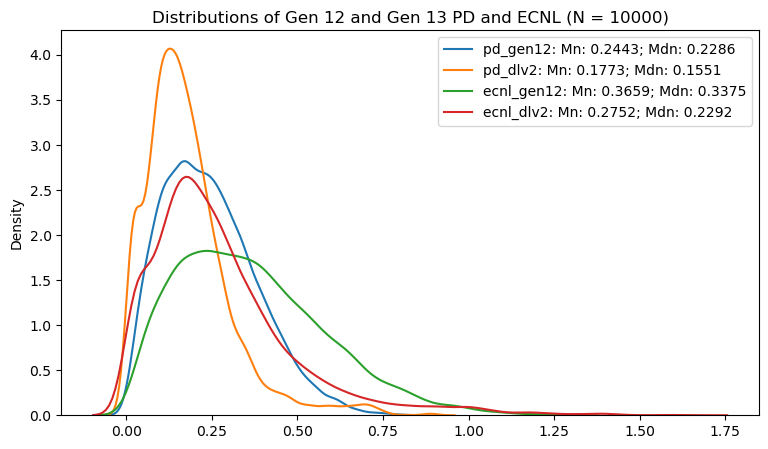

In [12]:
int_nrows = df.shape[0]
list_cols = [
    'pd_gen12',
    'pd_dlv2',
    'ecnl_gen12',
    'ecnl_dlv2',
]
fig, ax = plt.subplots(figsize=(9,5))
ax.set_title(f'Distributions of Gen 12 and Gen 13 PD and ECNL (N = {int_nrows})')
for col in tqdm(list_cols):
    flt_mn = df[col].mean()
    flt_mdn = df[col].median()
    str_label = f'{col}: Mn: {flt_mn:0.4f}; Mdn: {flt_mdn:0.4f}'
    sns.kdeplot(list(df[col]), label=str_label)
# legend
ax.legend()

# save
str_filename = 'plt_distributions.png'
str_local_path =  f'{str_dirname_output}/{str_filename}'
plt.savefig(str_local_path, bbox_inches='tight')

# show
plt.show()

#### Show relationship


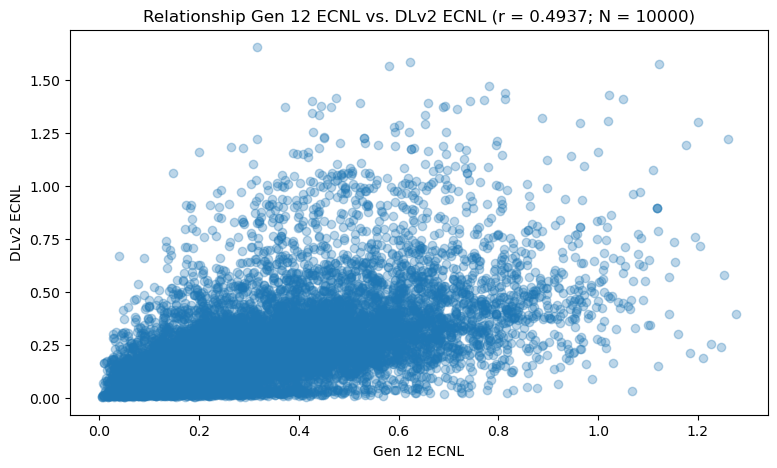

In [13]:
x = df['ecnl_gen12']
y = df['ecnl_dlv2']
flt_r = pearsonr(x, y)[0]
fig, ax = plt.subplots(figsize=(9,5))
ax.set_title(f'Relationship Gen 12 ECNL vs. DLv2 ECNL (r = {flt_r:0.4f}; N = {int_nrows})')
ax.set_xlabel('Gen 12 ECNL')
ax.set_ylabel('DLv2 ECNL')
ax.scatter(x, y, alpha=0.3)

# save
str_filename = 'plt_correlation.png'
str_local_path =  f'{str_dirname_output}/{str_filename}'
plt.savefig(str_local_path, bbox_inches='tight')

# show
plt.show()

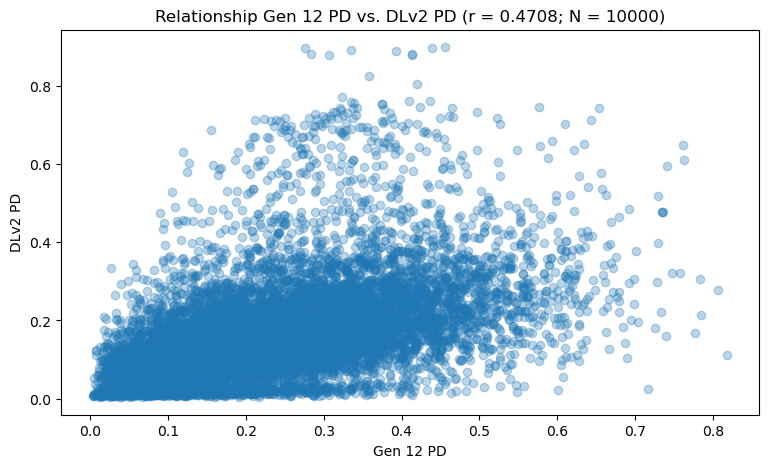

In [14]:
x = df['pd_gen12']
y = df['pd_dlv2']
flt_r = pearsonr(x, y)[0]
fig, ax = plt.subplots(figsize=(9,5))
ax.set_title(f'Relationship Gen 12 PD vs. DLv2 PD (r = {flt_r:0.4f}; N = {int_nrows})')
ax.set_xlabel('Gen 12 PD')
ax.set_ylabel('DLv2 PD')
ax.scatter(x, y, alpha=0.3)

# save
str_filename = 'plt_correlation_pd.png'
str_local_path =  f'{str_dirname_output}/{str_filename}'
plt.savefig(str_local_path, bbox_inches='tight')

# show
plt.show()

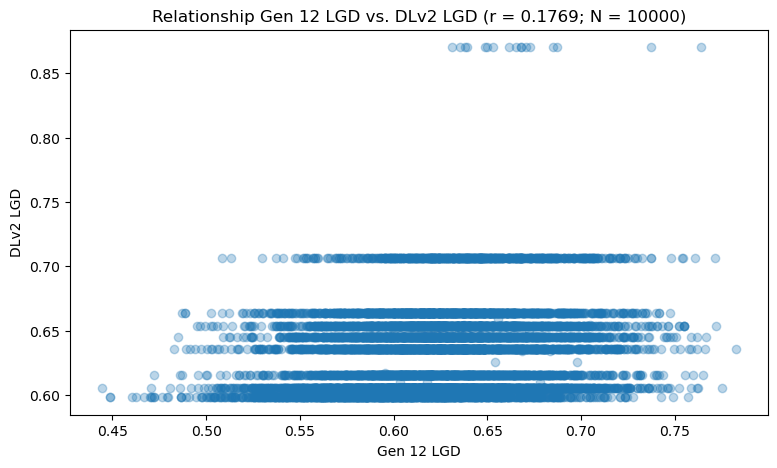

In [15]:
x = df['lgd_gen12']
y = df['lgd_dlv2']
flt_r = pearsonr(x, y)[0]
fig, ax = plt.subplots(figsize=(9,5))
ax.set_title(f'Relationship Gen 12 LGD vs. DLv2 LGD (r = {flt_r:0.4f}; N = {int_nrows})')
ax.set_xlabel('Gen 12 LGD')
ax.set_ylabel('DLv2 LGD')
ax.scatter(x, y, alpha=0.3)

# save
str_filename = 'plt_correlation_lgd.png'
str_local_path =  f'{str_dirname_output}/{str_filename}'
plt.savefig(str_local_path, bbox_inches='tight')

# show
plt.show()

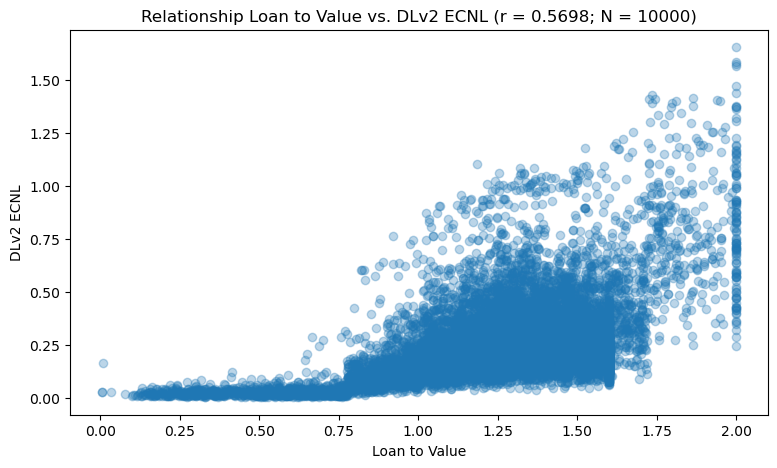

In [16]:
x = df['ENG-loan_to_value'].fillna(1.27)
y = df['ecnl_dlv2']
flt_r = pearsonr(x, y)[0]
if pd.isnull(flt_r):
    flt_r = spearmanr(x, y)[0]
else:
    pass
fig, ax = plt.subplots(figsize=(9,5))
ax.set_title(f'Relationship Loan to Value vs. DLv2 ECNL (r = {flt_r:0.4f}; N = {int_nrows})')
ax.set_xlabel('Loan to Value')
ax.set_ylabel('DLv2 ECNL')
ax.scatter(x, y, alpha=0.3)

# save
str_filename = 'plt_correlation_ltv_ecnl.png'
str_local_path =  f'{str_dirname_output}/{str_filename}'
plt.savefig(str_local_path, bbox_inches='tight')

# show
plt.show()

#### Analyze PD threshold

In [17]:
# gen 12
int_nrows = df[(df['pd_gen12'] <= flt_threshold_pd) & (df['ecnl_gen12'] <= dict_tiers['D'])].shape[0]
flt_prop = int_nrows / df.shape[0]
print(f'Gen 12 Approvals Considering PD Threshold ({flt_threshold_pd:0.2f}): {flt_prop:0.4f}')

Gen 12 Approvals Considering PD Threshold (0.60): 0.5219


In [18]:
# what prop were declined by pd but approved by ecnl
int_nrows = df[(df['pd_gen12'] > flt_threshold_pd) & (df['ecnl_gen12'] <= dict_tiers['D'])].shape[0]
flt_prop = int_nrows / df.shape[0]
print(f'Gen 12 Approvals Declined by PD Threshold ({flt_threshold_pd:0.2f}): {flt_prop:0.6f}')

Gen 12 Approvals Declined by PD Threshold (0.60): 0.000000


In [19]:
# gen 13
int_nrows = df[(df['pd_dlv2'] <= flt_threshold_pd) & (df['ecnl_dlv2'] <= dict_tiers['D'])].shape[0]
flt_prop = int_nrows / df.shape[0]
print(f'DLv2 Approvals Considering PD Threshold ({flt_threshold_pd:0.2f}): {flt_prop:0.4f}')

DLv2 Approvals Considering PD Threshold (0.60): 0.7392


In [20]:
# what prop were declined by pd but approved by ecnl
int_nrows = df[(df['pd_dlv2'] > flt_threshold_pd) & (df['ecnl_dlv2'] <= dict_tiers['D'])].shape[0]
flt_prop = int_nrows / df.shape[0]
print(f'DLv2 Approvals Declined by PD Threshold ({flt_threshold_pd:0.2f}): {flt_prop:0.6f}')

DLv2 Approvals Declined by PD Threshold (0.60): 0.000000


#### Create tier

In [21]:
# gen 12
df['tier_gen12'] = df['ecnl_gen12'].apply(
    lambda x: get_tier(
        flt_ecnl=x,
        dict_tiers=dict_tiers,
    ),
)
# gen 13
df['tier_dlv2'] = df['ecnl_dlv2'].apply(
    lambda x: get_tier(
        flt_ecnl=x,
        dict_tiers=dict_tiers,
    ),
)
# show
df

,accountid,pd_gen12,lgd_gen12,ecnl_gen12,request_datetime,pd_dlv2,lgd_dlv2,ecnl_dlv2,intopenbktype__app,ENG-loan_to_value,strdealershiptrackertype__app,fltgrossmonthly__income_sum,miles_odometer__app,tier_gen12,tier_dlv2
0,8321703,0.115847,0.630854,0.172474,2024-11-27 21:53:12+00:00,0.226087,0.635684,0.317471,NaN,1.304611,Referral,4379.20,69144,B,C
1,8353245,0.089682,0.563194,0.119200,2024-12-04 23:32:24+00:00,0.087583,0.635684,0.122984,NaN,1.219764,Referral,8923.01,97249,A,A
2,8375603,0.043439,0.591126,0.060600,2024-12-02 23:02:52+00:00,0.123767,0.605262,0.165476,NaN,1.101235,Referral,8233.33,56150,A1,B
3,8380765,0.131776,0.561194,0.174526,2024-12-10 04:19:45+00:00,0.239989,0.615474,0.419352,NaN,1.135986,Referral,6998.09,30237,B,Decline
4,8383502,0.036059,0.573853,0.048835,2024-11-27 05:41:46+00:00,0.054071,0.605262,0.072293,NaN,0.954679,Referral,10034.96,52621,A1,A1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,8627588,0.305816,0.729014,0.526148,2025-02-07 06:40:52+00:00,0.201369,0.635684,0.282762,NaN,1.243941,Franchise,7401.00,40301,Decline,C
9996,8627590,0.303960,0.728410,0.522523,2025-02-07 06:41:04+00:00,0.219424,0.635684,0.308115,NaN,1.217199,Franchise,7500.00,79000,Decline,C
9997,8627613,0.176644,0.654692,0.272928,2025-02-07 06:47:03+00:00,0.067110,0.605262,0.089726,NaN,0.993862,Franchise,10833.00,42200,C,A
9998,8627659,0.306193,0.646098,0.466880,2025-02-07 06:57:18+00:00,0.147441,0.605262,0.197129,NaN,0.967878,Franchise,5400.00,86000,Decline,B


#### Tag approved and declined

In [22]:
# gen 12 - approved
df['approved_gen12'] = df['tier_gen12'].apply(
    lambda x: 1 if x != 'Decline' else 0,
)
# dlv2 - approved
df['approved_dlv2'] = df['tier_dlv2'].apply(
    lambda x: 1 if x != 'Decline' else 0,
)

# gen 12 - declined
df['declined_gen12'] = df['tier_gen12'].apply(
    lambda x: 1 if x == 'Decline' else 0,
)
# dlv2 - declined
df['declined_dlv2'] = df['tier_dlv2'].apply(
    lambda x: 1 if x == 'Decline' else 0,
)
# approved by both
df['approved_both'] = df.apply(
    lambda x: 1 if (x['tier_gen12'] != 'Decline') and (x['tier_dlv2'] != 'Decline') else 0,
    axis=1,
)
# declined by both
df['declined_both'] = df.apply(
    lambda x: 1 if (x['tier_gen12'] == 'Decline') and (x['tier_dlv2'] == 'Decline') else 0,
    axis=1,
)
# approved gen 12 - declined dlv2
df['approved_gen12_declined_dlv2'] = df.apply(
    lambda x: 1 if (x['tier_gen12'] != 'Decline') and (x['tier_dlv2'] == 'Decline') else 0,
    axis=1,
)
# declined gen 12 - approved dlv2
df['declined_gen12_approved_dlv2'] = df.apply(
    lambda x: 1 if (x['tier_gen12'] == 'Decline') and (x['tier_dlv2'] != 'Decline') else 0,
    axis=1,
)

# reorder
list_cols = [
    'accountid',
    'request_datetime',
]
list_cols_end = [col for col in df.columns if col not in list_cols]
list_cols = list_cols + list_cols_end
df = df[list_cols].copy()

# sort
df.sort_values(by='ecnl_gen12', ascending=True, inplace=True)

# save
str_filename = 'df_swap_in_swap_out.csv'
str_local_path = f'{str_dirname_output}/{str_filename}'
df.to_csv(str_local_path, index=False)

# show
df

,accountid,request_datetime,pd_gen12,lgd_gen12,ecnl_gen12,pd_dlv2,lgd_dlv2,ecnl_dlv2,intopenbktype__app,ENG-loan_to_value,...,tier_gen12,tier_dlv2,approved_gen12,approved_dlv2,declined_gen12,declined_dlv2,approved_both,declined_both,approved_gen12_declined_dlv2,declined_gen12_approved_dlv2
2579,8487108,2024-12-14 12:10:12+00:00,0.003870,0.548565,0.005010,0.005792,0.598191,0.007654,NaN,0.617436,...,A1,A1,1,1,0,0,1,0,0,0
4066,8517402,2024-12-24 01:05:22+00:00,0.004118,0.531872,0.005169,0.005899,0.598191,0.007795,NaN,0.481928,...,A1,A1,1,1,0,0,1,0,0,0
4388,8520613,2024-12-26 22:14:31+00:00,0.004706,0.498030,0.005532,0.008281,0.598191,0.010943,NaN,0.726480,...,A1,A1,1,1,0,0,1,0,0,0
4304,8520386,2024-12-26 05:30:43+00:00,0.004628,0.568065,0.006204,0.011812,0.598191,0.015609,NaN,0.534933,...,A1,A1,1,1,0,0,1,0,0,0
4459,8521534,2024-12-27 01:48:45+00:00,0.004918,0.544012,0.006314,0.008950,0.598191,0.011827,NaN,0.516813,...,A1,A1,1,1,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8684,8608790,2025-01-31 05:15:33+00:00,0.725532,0.716156,1.226242,0.180478,0.635684,0.253427,NaN,1.252183,...,Decline,B,0,1,1,0,0,0,0,1
6727,8583158,2025-01-21 22:54:34+00:00,0.776646,0.680020,1.246399,0.167970,0.645319,0.239438,NaN,1.406142,...,Decline,B,0,1,1,0,0,0,0,1
6889,8585186,2025-01-22 08:16:01+00:00,0.746641,0.710281,1.251567,0.321122,0.635684,0.579548,NaN,1.263451,...,Decline,Decline,0,0,1,1,0,1,0,0
6683,8582923,2025-01-21 14:11:05+00:00,0.762029,0.700689,1.260110,0.609873,0.706772,1.223760,NaN,1.644786,...,Decline,Decline,0,0,1,1,0,1,0,0


#### Rates

100%|██████████| 8/8 [00:00<00:00, 9805.50it/s]


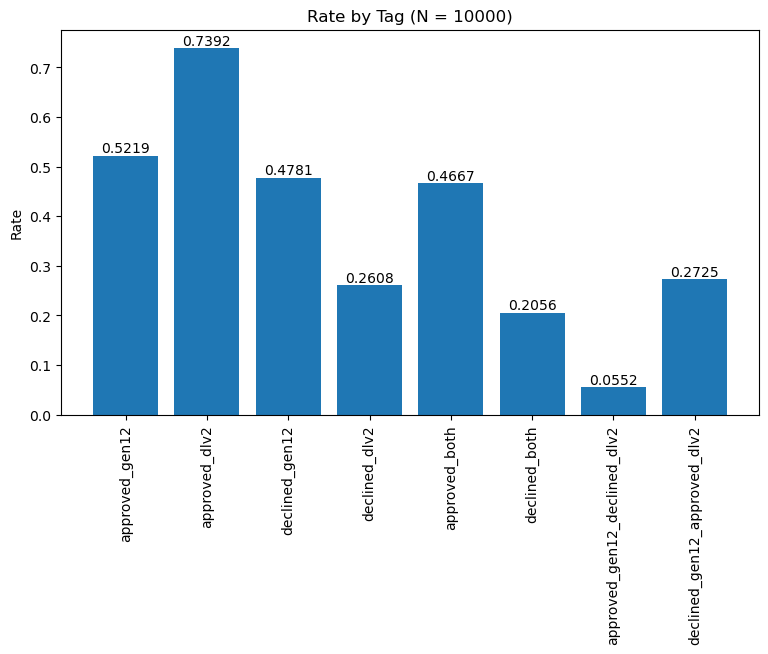

In [23]:
int_nrows = df.shape[0]
list_cols = [
    'approved_gen12',
    'approved_dlv2',
    'declined_gen12',
    'declined_dlv2',
    'approved_both',
    'declined_both',
    'approved_gen12_declined_dlv2',
    'declined_gen12_approved_dlv2',
]
list_dict_row = []
for col in tqdm(list_cols):
    # get mean
    flt_mean = df[col].mean()
    # row
    dict_row = {
        'column': col,
        'mean': flt_mean,
    }
    list_dict_row.append(dict_row)
df_tmp = pd.DataFrame(list_dict_row)

# plot
x = df_tmp['column']
fig, ax = plt.subplots(figsize=(9,5))
ax.set_title(f'Rate by Tag (N = {int_nrows})')
ax.set_ylabel('Rate')
bars = ax.bar(x, df_tmp['mean'])
ax.set_xticklabels(x, rotation=90)
ax.bar_label(bars, fmt='%.4f')

# save
str_filename = 'plt_swap_in_swap_out.png'
str_local_path =  f'{str_dirname_output}/{str_filename}'
plt.savefig(str_local_path, bbox_inches='tight')

# show
plt.show()